In [70]:
import pandas as pd
import json

from sklearn.feature_extraction.text import CountVectorizer

In [71]:
# Load the Yelp business dataset using pandas read_json
# Added lines=True to designate each line to represent a complete JSON object
biz_df = pd.read_json('yelp_academic_dataset_business.json', lines=True)
biz_df.shape

(150346, 14)

In [72]:
biz_df.head(3)

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours
0,Pns2l4eNsfO8kk83dixA6A,"Abby Rappoport, LAC, CMQ","1616 Chapala St, Ste 2",Santa Barbara,CA,93101,34.426679,-119.711197,5.0,7,0,{'ByAppointmentOnly': 'True'},"Doctors, Traditional Chinese Medicine, Naturop...",None
1,mpf3x-BjTdTEA3yCZrAYPw,The UPS Store,87 Grasso Plaza Shopping Center,Affton,MO,63123,38.551126,-90.335695,3.0,15,1,{'BusinessAcceptsCreditCards': 'True'},"Shipping Centers, Local Services, Notaries, Ma...","{'Monday': '0:0-0:0', 'Tuesday': '8:0-18:30', ..."
2,tUFrWirKiKi_TAnsVWINQQ,Target,5255 E Broadway Blvd,Tucson,AZ,85711,32.223236,-110.880452,3.5,22,0,"{'BikeParking': 'True', 'BusinessAcceptsCredit...","Department Stores, Shopping, Fashion, Home & G...","{'Monday': '8:0-22:0', 'Tuesday': '8:0-22:0', ..."


In [73]:
# Open a json file in read mode
#f = open('yelp_academic_dataset_review.json','r', encoding='utf-8')
#js = []

# Append the first 10,000 rows into a dataset
#for i in range(10000):
#    js.append(json.loads(f.readline()))
#f.close()
#review_df = pd.DataFrame(js)

# Return the shape
#review_df.shape

In [74]:
from langdetect import detect, LangDetectException

# Open a json file in read mode
f = open('yelp_academic_dataset_review.json','r', encoding='utf-8')
js = []

# Append the first 10,000 rows into a dataset if the text is English
i = 0
while i < 10000:
    jrl = json.loads(f.readline())
    if detect(jrl['text']) =='en':
        #print(jrl)
        js.append(jrl)
        i +=1    
f.close()
review_df = pd.DataFrame(js)

# Return the shape
review_df.shape

(10000, 9)

In [75]:
# Display the first 2 rows
review_df.head(2)

,review_id,user_id,business_id,stars,useful,funny,cool,text,date
0,KU_O5udG6zpxOg-VcAEodg,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3.0,0,0,0,"If you decide to eat here, just be aware it is...",2018-07-07 22:09:11
1,BiTunyQ73aT9WBnpR9DZGw,OyoGAe7OKpv6SyGZT5g77Q,7ATYjTIgM3jUlt4UM3IypQ,5.0,1,0,1,I've taken a lot of spin classes over the year...,2012-01-03 15:28:18


In [76]:
# Display the text feature of the first row
review_df['text'][0]

"If you decide to eat here, just be aware it is going to take about 2 hours from beginning to end. We have tried it multiple times, because I want to like it! I have been to it's other locations in NJ and never had a bad experience. \n\nThe food is good, but it takes a very long time to come out. The waitstaff is very young, but usually pleasant. We have just had too many experiences where we spent way too long waiting. We usually opt for another diner or restaurant on the weekends, in order to be done quicker."

In [77]:
# Instantiate a CountVectorizer
# (?u) enables Unicode support
# \\b matches a word boundary. Only words are captured
# \\w+ matches one or more workd characters

# CountVectorizer extracts sequences of one or more word characters, 
# bounded by word boundaries, and correctly handles Unicode characters. 
# This effectively tokenizes the text into individual words, excluding 
# punctuation and special characters, unless they are part of a 
# word (e.g., _). This differs from the default token_pattern in 
# CountVectorizer, which is r"(?u)\b\w\w+\b" and would exclude 
# single-character tokens.

bow_converter = CountVectorizer(token_pattern='(?u)\\b\\w+\\b')

In [78]:
# Fit and transform the review_df text feature
X = bow_converter.fit_transform(review_df['text'])

# Return the vocabulary size of the bow_converter
words = bow_converter.get_feature_names_out()
print(f'Vocabulary size: {len(words)}')

# Display the first 10 rows
print(f'{words[:10]}')

Vocabulary size: 24366
['0' '00' '000' '00000' '007' '00am' '00pm' '01' '02' '02pm']


In [79]:
#Instantiate a bigram CounterVectorize
bigram_converter = CountVectorizer(ngram_range=(2,2), 
                                   token_pattern='(?u)\\b\\w+\\b')

# Fit and transform the review_df text feature 
X2 = bigram_converter.fit_transform(review_df['text'])

# Return the vocabulary size of the bigram converter
words2 = bigram_converter.get_feature_names_out()
print(f'Bigam vocabulary size: {len(words2)}')

# Display the last 10 rows
print(f'{words2[-10:]}')

Bigam vocabulary size: 294037
['étouffée and' 'étouffée but' 'étouffée had' 'étouffée i' 'étouffée or'
 'étouffée sauce' 'étouffée was' 'étouffée with' 'öko bomb' '三杯鸡 oyster']


In [81]:
# Instantiate a trigram CounterVectorize
trigram_converter = CountVectorizer(ngram_range=(3,3))

# Fit and transform the review_df text feature
X3 = trigram_converter.fit_transform(review_df['text'])

# Return the vocabulary size of the trigram converter
words3 = trigram_converter.get_feature_names_out()
print(f'Trigram vocabulary size: {len(words3)}')

# Display the first 10 rows
print(f'{words3[:10]}')

Trigram vocabulary size: 687776
['00 00 am' '00 00 pm' '00 34 00' '00 79 keep' '00 95 they' '00 all day'
 '00 am and' '00 am on' '00 am or' '00 am that']


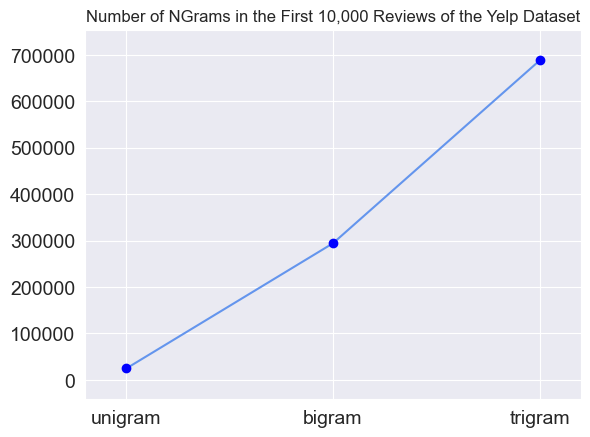

In [85]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("darkgrid")
counts = [len(words), len(words2), len(words3)]
plt.plot(counts, color='cornflowerblue')
plt.plot(counts, 'bo')
plt.margins(0.1)
plt.xticks(range(3), ['unigram','bigram','trigram'])
plt.tick_params(labelsize=14)
plt.title('Number of NGrams in the First 10,000 Reviews of the Yelp Dataset')
plt.show()

In [86]:
import spacy

In [88]:
# Model meta data
#spacy.info('en')

In [94]:
# Load the english corpus
nlp = spacy.load('en_core_web_sm')

In [96]:
# Create series of spaCy nlp variable
doc_df = review_df['text'].apply(nlp)

In [97]:
doc_df[4]

Cute interior and owner (?) gave us tour of upcoming patio/rooftop area which will be great on beautiful days like today. Cheese curds were very good and very filling. Really like that sandwiches come w salad, esp after eating too many curds! Had the onion, gruyere, tomato sandwich. Wasn't too much cheese which I liked. Needed something else...pepper jelly maybe. Would like to see more menu options added such as salads w fun cheeses. Lots of beer and wine as well as limited cocktails. Next time I will try one of the draft wines.

In [119]:
# Provide part of speech for each word in the doc_df[4] row for the first 10 words
for doc in doc_df[4][:10]:
    print(doc.text, doc.pos_, doc.tag_)

Cute ADJ JJ
interior NOUN NN
and CCONJ CC
owner NOUN NN
( PUNCT -LRB-
? PUNCT .
) PUNCT -RRB-
gave VERB VBD
us PRON PRP
tour NOUN NN


In [120]:
# Provide noun chunks for the doc_df[4] row
print([chunk for chunk in doc_df[4].noun_chunks])

[Cute interior, owner, us, tour, upcoming patio/rooftop area, which, beautiful days, today, Cheese curds, that sandwiches, too many curds, the onion, , tomato sandwich, too much cheese, which, I, something, more menu options, w fun cheeses, Lots, beer, wine, limited cocktails, I, the draft wines]


### Using Textblob

In [102]:
from textblob import TextBlob

In [113]:
#import nltk

# Download the nltk averaged_perceptron_tagger_eng corpus to use TextBLob
#nltk.download('averaged_perceptron_tagger_eng')

In [103]:
# Perform text feature transformation using TextBlob
blob_df = review_df['text'].apply(TextBlob)

In [115]:
# Provide part of speech for each word in the doc_df[4] row
#blob_df[4].tag

# Show the first 10 parts of speech in the text cell
for word, tag in blob_df[4].tags[:10]:
    print(f"Word: {word}, Tag: {tag}")

Word: Cute, Tag: NNP
Word: interior, Tag: NN
Word: and, Tag: CC
Word: owner, Tag: NN
Word: gave, Tag: VBD
Word: us, Tag: PRP
Word: tour, Tag: NN
Word: of, Tag: IN
Word: upcoming, Tag: VBG
Word: patio/rooftop, Tag: JJ


In [117]:
print([np for np in blob_df[4].noun_phrases])

['cute', 'patio/rooftop area', 'beautiful days', 'cheese', 'really', 'w salad', 'tomato sandwich', 'was', 'needed', '... pepper', 'menu options', 'salads w fun cheeses', 'lots', 'draft wines']
